In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import SVD, Dataset
print("All imports successful")
# Load all datasets
ratings = pd.read_csv('data/ml-latest-small/ratings.csv')
movies = pd.read_csv('data/ml-latest-small/movies.csv')
tags = pd.read_csv('data/ml-latest-small/tags.csv')
links = pd.read_csv('data/ml-latest-small/links.csv')

# Shape of each file
print("=== Dataset Shapes ===")
print(f"Ratings:  {ratings.shape}")
print(f"Movies:   {movies.shape}")
print(f"Tags:     {tags.shape}")
print(f"Links:    {links.shape}")

# Column names and data types
print("\n=== Ratings Columns ===")
print(ratings.dtypes)

print("\n=== Movies Columns ===")
print(movies.dtypes)

# First look at each
print("\n=== Ratings Sample ===")
print(ratings.head())

print("\n=== Movies Sample ===")
print(movies.head())

# Check for missing values
print("=== Missing Values ===")
print(f"Ratings:  {ratings.isnull().sum().sum()}")
print(f"Movies:   {movies.isnull().sum().sum()}")
print(f"Tags:     {tags.isnull().sum().sum()}")
print(f"Links:    {links.isnull().sum().sum()}")

# Check for duplicate ratings (same user rating same movie twice)
print("\n=== Duplicate Ratings ===")
duplicates = ratings.duplicated(subset=['userId', 'movieId']).sum()
print(f"Duplicate user-movie pairs: {duplicates}")

# Rating value distribution
print("\n=== Rating Value Counts ===")
print(ratings['rating'].value_counts().sort_index())

# Basic stats on ratings
print("\n=== Rating Statistics ===")
print(ratings['rating'].describe())

All imports successful
=== Dataset Shapes ===
Ratings:  (100836, 4)
Movies:   (9742, 3)
Tags:     (3683, 4)
Links:    (9742, 3)

=== Ratings Columns ===
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

=== Movies Columns ===
movieId    int64
title        str
genres       str
dtype: object

=== Ratings Sample ===
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

=== Movies Sample ===
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Com

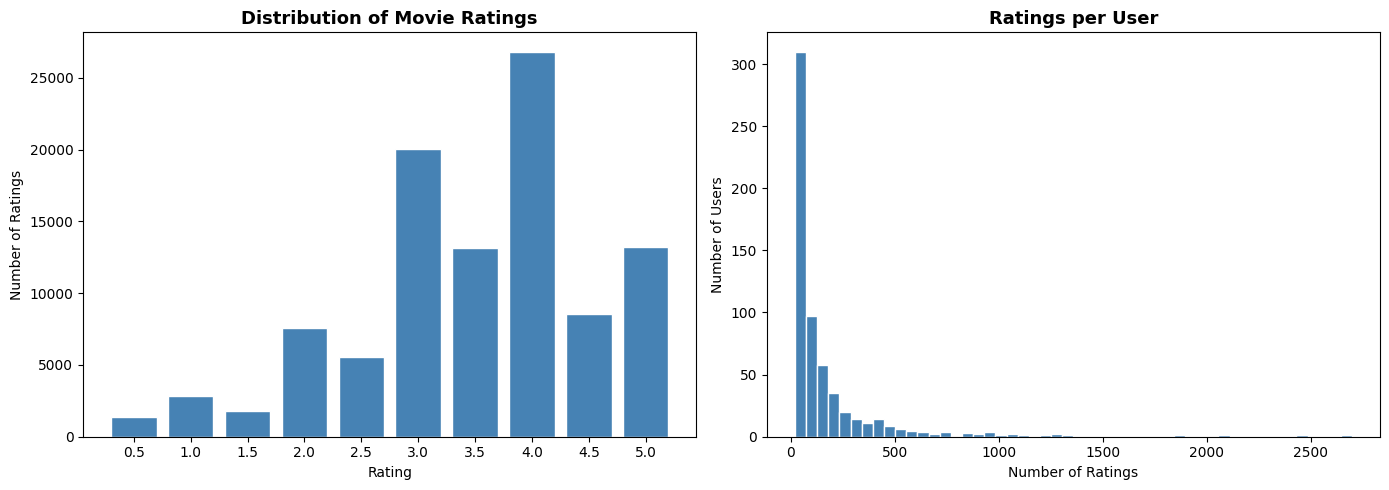


Ratings per user — Min: 20, Max: 2698, Median: 70.5


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Rating distribution
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, width=0.4, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Movie Ratings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Ratings')
axes[0].set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

# Chart 2 - Ratings per user
ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('charts/ratings_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRatings per user — Min: {ratings_per_user.min()}, Max: {ratings_per_user.max()}, Median: {ratings_per_user.median()}")

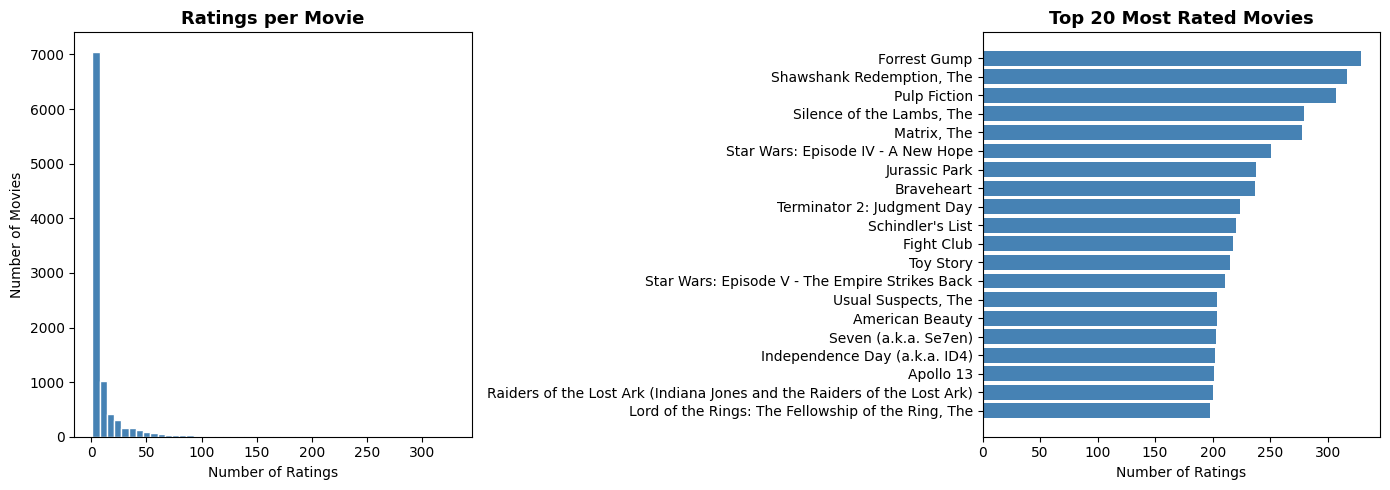


Ratings per movie — Min: 1, Max: 329, Median: 3.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 3 - Ratings per movie
ratings_per_movie = ratings.groupby('movieId').size()
axes[0].hist(ratings_per_movie, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per Movie', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')

# Chart 4 - Top 20 most rated movies
top_movies = ratings.groupby('movieId').size().reset_index(name='count')
top_movies = top_movies.merge(movies[['movieId', 'title']], on='movieId')
top_movies = top_movies.sort_values('count', ascending=False).head(20)
top_movies['title'] = top_movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

axes[1].barh(top_movies['title'][::-1], top_movies['count'][::-1], color='steelblue')
axes[1].set_title('Top 20 Most Rated Movies', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig('charts/movie_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRatings per movie — Min: {ratings_per_movie.min()}, Max: {ratings_per_movie.max()}, Median: {ratings_per_movie.median()}")

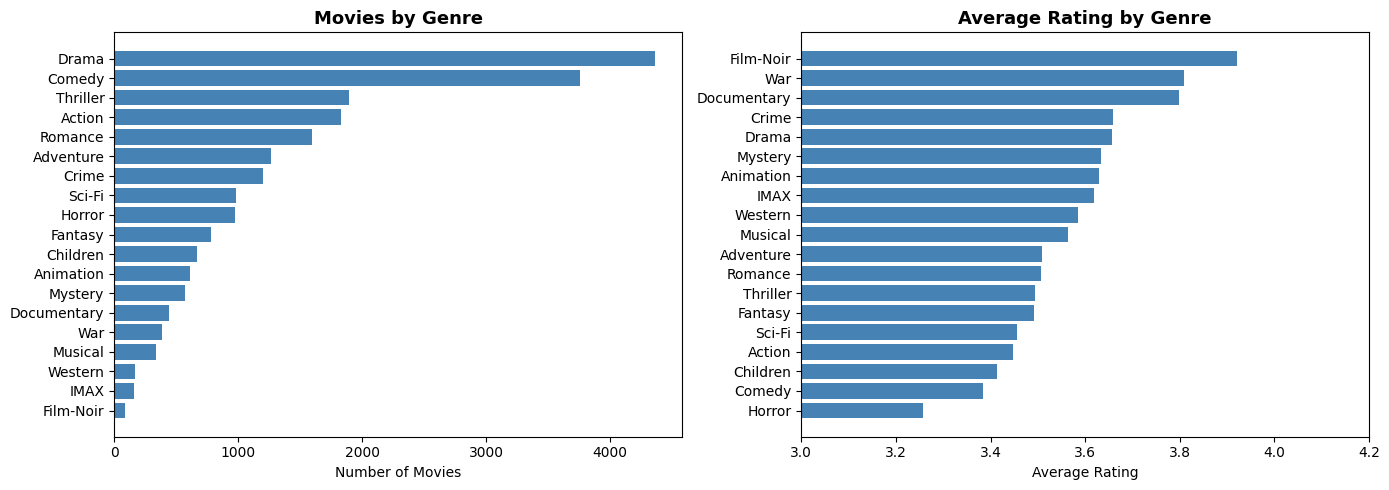


=== Top 5 Genres by Movie Count ===
genres
Drama       4361
Comedy      3756
Thriller    1894
Action      1828
Romance     1596
Name: count, dtype: int64

=== Average Rating by Genre ===
genre
Film-Noir      3.920115
War            3.808294
Documentary    3.797785
Crime          3.658294
Drama          3.656184
Mystery        3.632460
Animation      3.629937
IMAX           3.618335
Western        3.583938
Musical        3.563678
Adventure      3.508609
Romance        3.506511
Thriller       3.493706
Fantasy        3.491001
Sci-Fi         3.455721
Action         3.447984
Children       3.412956
Comedy         3.384721
Horror         3.258195
Name: rating, dtype: float64


In [6]:
from collections import Counter

# Split pipe-separated genres and count each
all_genres = movies['genres'].str.split('|').explode()
all_genres = all_genres[all_genres != '(no genres listed)']
genre_counts = all_genres.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 5 - Genre frequency
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue')
axes[0].set_title('Movies by Genre', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Movies')

# Chart 6 - Average rating by genre
movies_exploded = movies.copy()
movies_exploded['genre'] = movies['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genre')
movies_exploded = movies_exploded[movies_exploded['genre'] != '(no genres listed)']

genre_ratings = movies_exploded.merge(ratings, on='movieId')
avg_rating_by_genre = genre_ratings.groupby('genre')['rating'].mean().sort_values()

axes[1].barh(avg_rating_by_genre.index, avg_rating_by_genre.values, color='steelblue')
axes[1].set_title('Average Rating by Genre', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.0, 4.2)

plt.tight_layout()
plt.savefig('charts/genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Top 5 Genres by Movie Count ===")
print(genre_counts.head())
print("\n=== Average Rating by Genre ===")
print(avg_rating_by_genre.sort_values(ascending=False))

=== Ratings Matrix Sparsity ===
Unique users:       610
Unique movies:      9724
Total ratings:      100836
Possible ratings:   5,931,640
Sparsity:           98.3000%


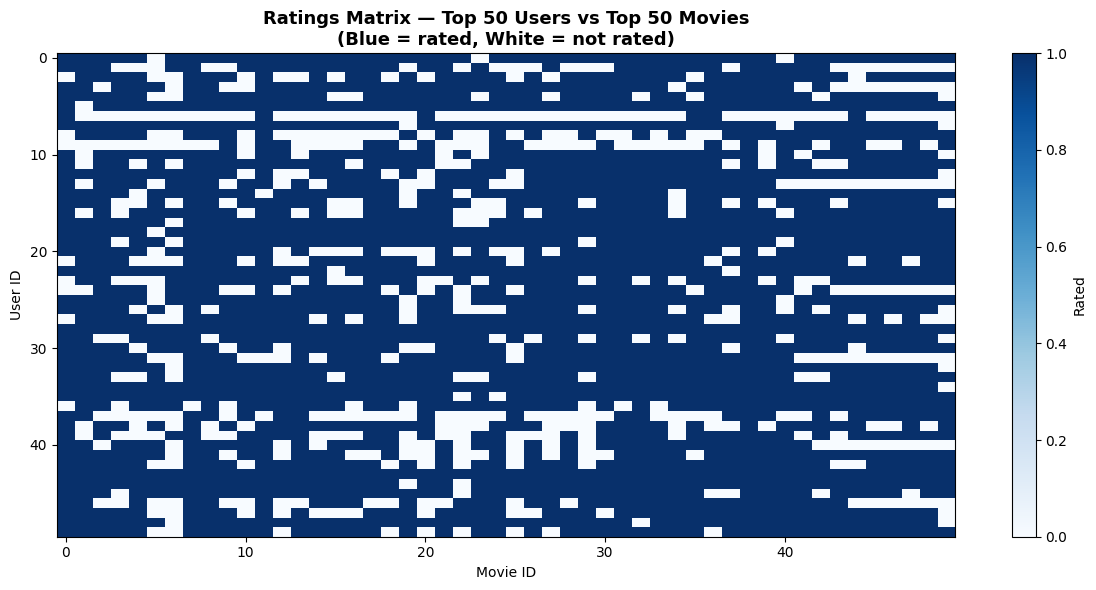

In [7]:
# Sparsity calculation
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print("=== Ratings Matrix Sparsity ===")
print(f"Unique users:       {n_users}")
print(f"Unique movies:      {n_movies}")
print(f"Total ratings:      {n_ratings}")
print(f"Possible ratings:   {n_users * n_movies:,}")
print(f"Sparsity:           {sparsity:.4%}")

# Chart 7 - Sparsity heatmap using a sample
sample_users = ratings['userId'].value_counts().head(50).index
sample_movies = ratings['movieId'].value_counts().head(50).index

sample_matrix = ratings[
    ratings['userId'].isin(sample_users) &
    ratings['movieId'].isin(sample_movies)
].pivot_table(index='userId', columns='movieId', values='rating')

plt.figure(figsize=(12, 6))
plt.imshow(sample_matrix.notna(), aspect='auto', cmap='Blues', interpolation='none')
plt.title('Ratings Matrix — Top 50 Users vs Top 50 Movies\n(Blue = rated, White = not rated)', fontsize=13, fontweight='bold')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.colorbar(label='Rated')
plt.tight_layout()
plt.savefig('charts/sparsity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()